# Phase 3: Expirementation with Kronecker Sequences

First we must import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import time
import matplotlib.ticker as mtick


# Import Calculations for Zaremba Index
from math_help import rho_box1_numpy, rho_box_bruteforce, rho_box_lyness, rho_3d_lyness, generate_optimized_g_vectors_3d, rho_4d_lyness, rho_5d_lyness, generate_optimized_g_vectors_4d, generate_optimized_g_vectors_5d

# Import Dataframe Helper
from experiment import bound_sufficiency_df

 Code that Calculates Lower Bound for $\rho$ $\le$ $\frac{C_d \cdot N}{(\log N)^{d-1}}$

In [2]:
def calculate_explicit_threshold(N, d=3):
    """
    Calculates the theoretical lower bound for rho based on the explicit 
    formula: (C_d * N) / (log N)^(d-1)
    """
    # 1. Calculate the constant C_d = (d - 1)! / 2^(d-1)
    C_d = math.factorial(d - 1) / (2**(d - 1))
    
    # 2. Calculate the threshold
    threshold = (C_d * N) / (math.log(N)**(d - 1))
    
    return threshold

First we will run simulations in 3D

N Values: 101, 251, 503, 1009 - Prime Numbers so that  $\gcd(g, N) = 1$

We look at $\mathbf{g}$ values using the symmetry principle to save time
- $g_1$ is always locked at $1$
- $g_2$ iterates from $1$ up to $N-1$
- $g_3$ iterates starting from $g_2$ up to $N-1$.

$\mathbf{g} = (1, g_2, g_3)$ 

The goal is to iterate through $\mathbf{g}$ values and find vector that beats threshold  ($\frac{0.5 \cdot N}{(\log N)^2}$)


In [4]:
def run_proportion_simulation():
    N_values = [101, 251, 503, 1009]
    results = {}
    
    print("Starting 3D Rank-1 Lattice Simulation...\n")
    
    for N in N_values:
        start_time = time.time()
        threshold = calculate_explicit_threshold(N, d=3)
        
        total_space = (N - 1)**2
        passing_weight = 0
        vectors_computed = 0
        
        # Iterate through the optimized search space
        for g_vector, weight in generate_optimized_g_vectors_3d(N):
            
            # Extract g2 and g3, convert to alpha1 and alpha2
            alpha_vector = (g_vector[1] / N, g_vector[2] / N)
            
            # Run the Lyness calculation and unpack the tuple
            actual_rho, _ = rho_3d_lyness(N, alpha_vector)
            vectors_computed += 1
            
            # Evaluate against the explicit Dick threshold
            if actual_rho >= threshold:
                passing_weight += weight
                
        # Calculate final metrics
        proportion = passing_weight / total_space
        results[N] = proportion
        elapsed_time = time.time() - start_time
        
        print(f"--- N = {N} ---")
        print(f"Threshold: {threshold:.4f}")
        print(f"Vectors Computed: {vectors_computed} (out of {total_space} total)")
        print(f"Passing Vectors: {passing_weight}")
        print(f"PROPORTION: {proportion:.2%} ({proportion:.6f})")
        print(f"Time taken: {elapsed_time:.2f} seconds\n")
        
    return results

# Run the simulation and store results
simulation_data = run_proportion_simulation()

Starting 3D Rank-1 Lattice Simulation...

--- N = 101 ---
Threshold: 2.3710
Vectors Computed: 5050 (out of 10000 total)
Passing Vectors: 9984
PROPORTION: 99.84% (0.998400)
Time taken: 0.11 seconds

--- N = 251 ---
Threshold: 4.1106
Vectors Computed: 31375 (out of 62500 total)
Passing Vectors: 62448
PROPORTION: 99.92% (0.999168)
Time taken: 1.71 seconds

--- N = 503 ---
Threshold: 6.4994
Vectors Computed: 126253 (out of 252004 total)
Passing Vectors: 251904
PROPORTION: 99.96% (0.999603)
Time taken: 13.05 seconds

--- N = 1009 ---
Threshold: 10.5454
Vectors Computed: 508536 (out of 1016064 total)
Passing Vectors: 1015856
PROPORTION: 99.98% (0.999795)
Time taken: 107.06 seconds



Graphing these Results we get...

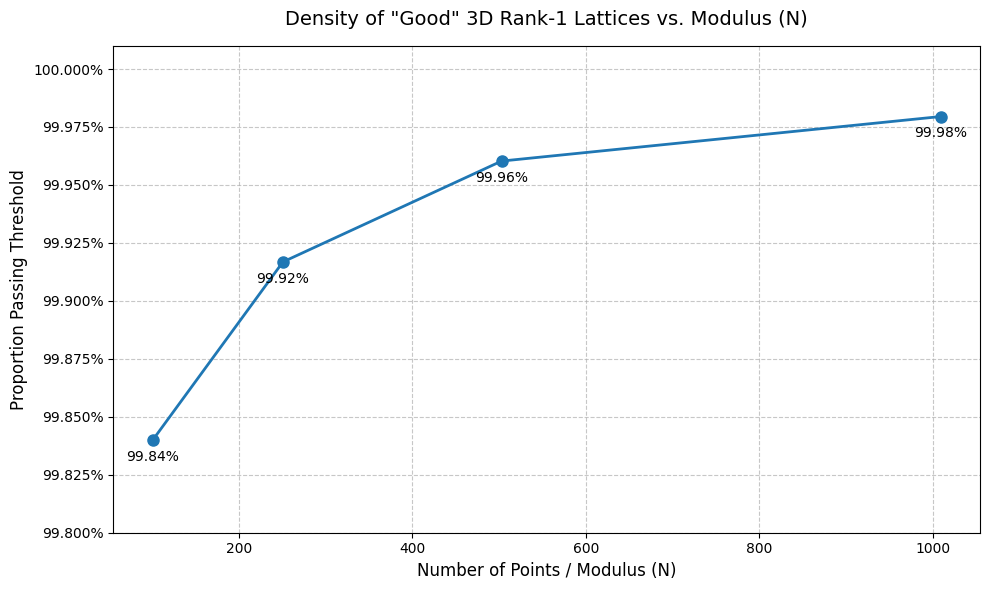

In [ ]:
results = {
    101: 0.998400,
    251: 0.999168,
    503: 0.999603,
    1009: 0.999795
}

N_values = list(results.keys())
proportions = list(results.values())

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(N_values, proportions, marker='o', linestyle='-', color='#1f77b4', linewidth=2, markersize=8)

# Formatting
plt.title('Density of "Good" 3D Rank-1 Lattices vs. Modulus (N)', fontsize=14, pad=15)
plt.xlabel('Number of Points / Modulus (N)', fontsize=12)
plt.ylabel('Proportion Passing Threshold', fontsize=12)

# Set Y-axis to percentage and tighten the window to show the subtle curve
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.ylim(0.998, 1.0001) 
plt.grid(True, linestyle='--', alpha=0.7)

# Add data labels
for x, y in zip(N_values, proportions):
    plt.annotate(f'{y:.2%}', 
                 (x, y), 
                 textcoords="offset points", 
                 xytext=(0, -15), 
                 ha='center',
                 fontsize=10)

plt.tight_layout()
plt.show()

This code although suspicious just tells us that the  explicit formula from the Dick 2018 paper ($\frac{C_d N}{(\log N)^{d-1}}$) is more so of a Worst-Case Guarantee instead of an elite filter.

Ovall howhever we can see that the proportion of N passing grows with the size of N in a pretty dramatic way with the size of N
- **N = 101:** 0.16% failure rate

- **N = 251:** 0.08% failure rate
- **N = 503:** 0.04% failure rate
- **N = 1009:** 0.02% failure rate

The failure rate is halfing every time N doubles

Next we wanna see at exactly at what size N is there at least 1 g value that passes the threshold. We will go 1 by 1 for prime numbers

In [9]:
small_primes = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 67, 71, 73, 79, 83, 89, 97, 101]

print("Hunting for the 'Sufficiently Large' Ignition Point in 3D...\n")
print(f"{'N':<5} | {'Threshold':<10} | {'Passing Vectors':<20} | {'Proportion':<10}")
print("-" * 55)
    
ignition_found = False
    
for N in small_primes:
    threshold = calculate_explicit_threshold(N, d=3)
    total_space = (N - 1)**2
    passing_weight = 0
        
    # Generator for optimized space
    for g_vector, weight in generate_optimized_g_vectors_3d(N):
        alpha_vector = (g_vector[1] / N, g_vector[2] / N)
        actual_rho, _ = rho_3d_lyness(N, alpha_vector)
            
        if actual_rho >= threshold:
            passing_weight += weight
                
    proportion = passing_weight / total_space
        
    print(f"{N:<5} | {threshold:<10.4f} | {passing_weight:<7} / {total_space:<9} | {proportion:.2%}")
        
    # Flag the exact moment the math kicks in
    if proportion > 0 and not ignition_found:
        print(f"\n>>> IGNITION POINT FOUND AT N = {N} <<<\n")
        ignition_found = True

Hunting for the 'Sufficiently Large' Ignition Point in 3D...

N     | Threshold  | Passing Vectors      | Proportion
-------------------------------------------------------
2     | 2.0814     | 0       / 1         | 0.00%
3     | 1.2428     | 0       / 4         | 0.00%
5     | 0.9651     | 16      / 16        | 100.00%

>>> IGNITION POINT FOUND AT N = 5 <<<

7     | 0.9243     | 36      / 36        | 100.00%
11    | 0.9565     | 100     / 100       | 100.00%
13    | 0.9880     | 144     / 144       | 100.00%
17    | 1.0589     | 252     / 256       | 98.44%
19    | 1.0958     | 320     / 324       | 98.77%
23    | 1.1697     | 480     / 484       | 99.17%
29    | 1.2788     | 780     / 784       | 99.49%
31    | 1.3144     | 896     / 900       | 99.56%
37    | 1.4189     | 1292    / 1296      | 99.69%
41    | 1.4865     | 1596    / 1600      | 99.75%
43    | 1.5198     | 1760    / 1764      | 99.77%
47    | 1.5853     | 2112    / 2116      | 99.81%
53    | 1.6811     | 2700    / 2704

Thus we can see that at **N = 5** is when there is at least 1 passing vector, lets check N = 4 to be exact.

In [10]:
def euler_totient(N):
    """Calculates the number of integers < N that are coprime to N."""
    count = 0
    for k in range(1, N):
        if math.gcd(N, k) == 1:
            count += 1
    return count

def generate_composite_safe_g_vectors_3d(N):
    """Generates vectors but FILTERS OUT any numbers that share factors with N."""
    for g2 in range(1, N):
        if math.gcd(g2, N) != 1:
            continue # Skip invalid numbers
            
        for g3 in range(g2, N): 
            if math.gcd(g3, N) != 1:
                continue # Skip invalid numbers
                
            weight = 1 if g2 == g3 else 2
            yield (1, g2, g3), weight

def test_exact_N(N):
    threshold = calculate_explicit_threshold(N, d=3)
    
    # The total space is now phi(N)^2, not (N-1)^2
    phi_N = euler_totient(N)
    total_space = phi_N**2
    
    passing_weight = 0
    
    print(f"Testing Exact Ignition for N = {N}")
    print(f"Threshold: {threshold:.4f}")
    print(f"Valid Coordinates: {[k for k in range(1, N) if math.gcd(N, k) == 1]}")
    print(f"Total Theoretical Space: {total_space} vectors\n")
    
    for g_vector, weight in generate_composite_safe_g_vectors_3d(N):
        alpha_vector = (g_vector[1] / N, g_vector[2] / N)
        actual_rho, _ = rho_3d_lyness(N, alpha_vector)
        
        print(f"Testing vector {g_vector} -> Zaremba Score: {actual_rho}")
        
        if actual_rho >= threshold:
            passing_weight += weight
            
    proportion = passing_weight / total_space if total_space > 0 else 0
    print(f"\nFinal Proportion: {proportion:.2%} ({passing_weight} / {total_space})")

# Let's check 4!
test_exact_N(4)

Testing Exact Ignition for N = 4
Threshold: 1.0407
Valid Coordinates: [1, 3]
Total Theoretical Space: 4 vectors

Testing vector (1, 1, 1) -> Zaremba Score: 1.0
Testing vector (1, 1, 3) -> Zaremba Score: 1.0
Testing vector (1, 3, 3) -> Zaremba Score: 1.0

Final Proportion: 0.00% (0 / 4)


Thus after this code we can see that for 3d the number of vectors passing the threshold for a certain N becomes > 0 at exactly 5

Now we will investigate in higher dimensions at 4d and 5d 

In [4]:
def run_high_d_crash_simulation():
    # Sticking to small primes because 5D space grows at (N-1)^4
    small_primes = [7, 11, 13, 17, 23]
    dimensions = [4, 5]
    
    for d in dimensions:
        print(f"\n{'='*50}")
        print(f"🚀 STARTING {d}D BRUTE-FORCE SWEEP")
        print(f"{'='*50}\n")
        
        for N in small_primes:
            start_time = time.time()
            
            threshold = calculate_explicit_threshold(N, d)
            total_space = (N - 1)**(d - 1)
            
            passing_weight = 0
            max_rho = 0
            best_vector = None
            vectors_computed = 0
            
            # Dynamically select the correct generator
            if d == 4:
                generator = generate_optimized_g_vectors_4d(N)
            else:
                generator = generate_optimized_g_vectors_5d(N)
                
            for g_vector, weight in generator:
                # Convert discrete g_vector (skipping the locked g1=1) to continuous alpha
                alpha_vector = tuple(g / N for g in g_vector[1:])
                
                # Dynamically select the correct Lyness calculation
                if d == 4:
                    actual_rho, _ = rho_4d_lyness(N, alpha_vector)
                else:
                    actual_rho, _ = rho_5d_lyness(N, alpha_vector)
                    
                vectors_computed += 1
                
                # 1. Tally passing vectors for the density crash
                if actual_rho >= threshold:
                    passing_weight += weight
                    
                # 2. Track the absolute mathematical ceiling
                if actual_rho > max_rho:
                    max_rho = actual_rho
                    best_vector = g_vector
                    
            proportion = passing_weight / total_space
            elapsed = time.time() - start_time
            
            print(f"--- N = {N} ---")
            print(f"Threshold: {threshold:.4f}")
            print(f"Proportion Passing: {proportion:.2%} ({passing_weight} / {total_space})")
            print(f"Absolute Best Vector: {best_vector} -> True rho: {max_rho}")
            print(f"Compute Time: {elapsed:.2f}s\n")

# Run the simulation
run_high_d_crash_simulation()


🚀 STARTING 4D BRUTE-FORCE SWEEP

--- N = 7 ---
Threshold: 0.7125
Proportion Passing: 100.00% (216 / 216)
Absolute Best Vector: (1, 2, 2, 4) -> True rho: 6.000000000000008
Compute Time: 0.00s

--- N = 11 ---
Threshold: 0.5984
Proportion Passing: 100.00% (1000 / 1000)
Absolute Best Vector: (1, 1, 3, 4) -> True rho: 11.0
Compute Time: 0.00s

--- N = 13 ---
Threshold: 0.5778
Proportion Passing: 100.00% (1728 / 1728)
Absolute Best Vector: (1, 1, 3, 5) -> True rho: 13.0
Compute Time: 0.00s

--- N = 17 ---
Threshold: 0.5606
Proportion Passing: 100.00% (4096 / 4096)
Absolute Best Vector: (1, 1, 3, 6) -> True rho: 17.0
Compute Time: 0.01s

--- N = 23 ---
Threshold: 0.5596
Proportion Passing: 100.00% (10648 / 10648)
Absolute Best Vector: (1, 1, 3, 8) -> True rho: 23.0
Compute Time: 0.04s


🚀 STARTING 5D BRUTE-FORCE SWEEP

--- N = 7 ---
Threshold: 0.7323
Proportion Passing: 100.00% (1296 / 1296)
Absolute Best Vector: (1, 1, 1, 3, 3) -> True rho: 7.0
Compute Time: 0.00s

--- N = 11 ---
Threshold:

We see that in these higher dimensions literally **100%** of vectors pass this threshold. This is because in higher dimensions the $(\log N)^{d-1}$ denominator is so aggressive that the formula is functionally useless for standard integration tasks. In higher dimensions, it acts as a 100% rubber stamp. But this is only for smaller N mathematically, as N approaches infinity, the numerator $N$ will mathematically overtake the $(\log N)^{d-1}$ denominator. The threshold does eventually work, it just takes a massive $N$ (around 3,000 for 5D) to cross the 1.0 mark. 